# Kitsap Build Script
May 17, 2026

Table of contents:

1. Debridging script
2. Quadtree build
3. Sanity Check Plot
4. Input File Build
5. Benchmark Load & Sanity Check

## Debridging

Imports and file paths

In [12]:
import numpy as np
import gc
import geopandas as gpd
from shapely.prepared import prep
from shapely.vectorized import contains
import rasterio
from rasterio.windows import Window
from rasterio.transform import xy

parent_dir = '/home/cassandra/Kitsap/2026-05-17/'
debridge_file = parent_dir + 'debridge.geojson'

dem_path = "/home/cassandra/Data/kitsap_DEM/KitsapCo_CoNED_DEMmods_v1.tif"
bdx, bdy = 1, 1
out_path = "/home/cassandra/Data/kitsap_DEM/KitsapCo_CoNED_DEMmods_v1_debridged.tif"

Prepare to debridge

In [13]:
debridge_shape = gpd.read_file(debridge_file)
prepared_geoms = [prep(g) for g in debridge_shape.geometry]

def Kitsap_debridge(xx, yy, z):
    # index first
    xmin, ymin = np.nanmin(xx), np.nanmin(yy)
    xmax, ymax = np.nanmax(xx), np.nanmax(yy)
    possible_matches = debridge_shape.sindex.intersection((xmin, ymin, xmax, ymax))
    if len(possible_matches) == 0:
        return z
    z_ret = np.copy(z)
    for pm in possible_matches:
        content_mask = contains(prepared_geoms[pm], xx, yy)
        if np.nansum(content_mask) > 0:
            z_ret[content_mask] = np.nanmin(z_ret[content_mask])
    return z_ret

Debridge with windows

In [14]:
window_size = 5*1024
with rasterio.open(dem_path) as src:
    profile = src.profile.copy()
    crs = src.crs
    profile.update(dtype="float32", nodata=np.nan, BIGTIFF='YES')
    # Create output file with same metadata
    with rasterio.open(out_path, 'w', **profile) as dst:
        # Iterate over windows
        print("Chunk Size:", window_size, 'x', window_size)
        print("Height:", src.height)
        print("Width:", src.width)
        for wyi in range(0, src.height, int(window_size)):
            print("Chunk", int(wyi/window_size)+1, 'of', int(src.height/window_size)+1)
            for wxi in range(0, src.width, int(window_size)):
                print('_',end='')
            print('')
            for wxi in range(0, src.width, int(window_size)):
                print('.',end='')
                # Define a window
                w = Window(wxi, wyi,
                           min(window_size, src.width - wxi),
                           min(window_size, src.height - wyi))
                # Read data for the window
                zb = src.read(window=w)
                # Read x, y
                # Rows and columns for this window
                rows = np.arange(w.height)
                cols = np.arange(w.width)
                # Compute x coordinates (center of each column)
                win_transform = src.window_transform(w)
                x, _ = xy(win_transform, 0 * np.ones_like(cols), cols, offset='center')
                # Compute y coordinates (center of each row)
                _, y = xy(win_transform, rows, 0 * np.ones_like(rows), offset='center')
                x = np.array(x)
                y = np.array(y)
                # get as meshgrid
                xx, yy = np.meshgrid(x, y)
                # Debridge!!!
                zb_debridged = np.array([Kitsap_debridge(xx, yy, zb[0])])
                # Write to new geotif
                dst.write(zb_debridged, window=w)
                # collect to try to keep memory leaks under control
                gc.collect()
            print('')

Chunk Size: 5120 x 5120
Height: 70080
Width: 44419
Chunk 1 of 14
_________
.........
Chunk 2 of 14
_________
.......

/tmp/ipykernel_250522/3641559682.py:13: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  content_mask = contains(prepared_geoms[pm], xx, yy)


..
Chunk 3 of 14
_________
.........
Chunk 4 of 14
_________
.........
Chunk 5 of 14
_________
.........
Chunk 6 of 14
_________
.........
Chunk 7 of 14
_________
.........
Chunk 8 of 14
_________
.........
Chunk 9 of 14
_________
.........
Chunk 10 of 14
_________
.........
Chunk 11 of 14
_________
.........
Chunk 12 of 14
_________
.........
Chunk 13 of 14
_________
.........
Chunk 14 of 14
_________
.........


## Quadtree Build

### Imports & File Paths

In [1]:
from hydromt_sfincs import SfincsModel

import os
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr

# Not included in the parent directory, for size concerns.
DEM_PATH = "/home/cassandra/Data/kitsap_DEM/KitsapCo_CoNED_DEMmods_v1_debridged.tif"
MAN_PATH = "/home/cassandra/Kitsap/kitsap_manning.tif"
manning_override = 0.02

# Parent Directory for shape files and sfincs model build files
parent_dir = '/home/cassandra/Kitsap/2026-05-17/'

# Shape files and other stuff
required_files = {
    "DEM":                 DEM_PATH,
    "MAN":                 MAN_PATH,
    "include":             parent_dir + "include.geojson",
    "offshore_boundary":   parent_dir + "waterbound.geojson",
    "refine_40m":          parent_dir + "refine_40m.geojson",
    "refine_20m-1":        parent_dir + "refine_20m_interest.geojson",
    "refine_20m-2":        parent_dir + "refine_20m_streams.geojson",
}

# Prep geodataframes, lists, etc
include_gdf  = gpd.read_file(required_files['include'])
offshore_gdf = gpd.read_file(required_files['offshore_boundary'])

refine_specs = [
    (required_files['refine_40m'],   2),
    (required_files['refine_20m-1'], 3),
    (required_files['refine_20m-2'], 3)]

refine_parts = []
for fpath, level in refine_specs:
    gdf = gpd.read_file(fpath)
    gdf = gdf[["geometry"]].copy()
    gdf["refinement_level"] = level
    refine_parts.append(gdf)

refinement_gdf = gpd.GeoDataFrame(
    pd.concat(refine_parts, ignore_index=True), crs=include_gdf.crs
)

elevation_list = [{"elevation": required_files['DEM']}]
roughness_list = [{"manning"  : required_files['MAN']}]

### Build Quadtree Files

In [2]:
sf = SfincsModel(root=parent_dir, mode="w+")

sf.quadtree_grid.create_from_region(
    region={"geom": include_gdf},
    res=160,
    crs=32610,
    rotated=False,
    refinement_polygons=refinement_gdf,
)

sf.quadtree_elevation.create(
    elevation_list=elevation_list,
    interp_method="linear",
    buffer_cells=1,
)

sf.quadtree_mask.create_active(
    include_polygon=include_gdf,
)

sf.quadtree_mask.create_boundary(
    btype="waterlevel",
    include_polygon=offshore_gdf,
    reset_bounds=True,
)

sf.quadtree_roughness.create(
    roughness_list=roughness_list,
    manning_land=manning_override,
    manning_sea=manning_override,
    rgh_lev_land=0,   # z = 0 m as land/sea boundary
)

No region component found in components.


Refining ...
Time elapsed : 17.235379695892334 s
Finding neighbors ...
Time elapsed : 0.041105031967163086 s
Setting neighbors left and below ...
Time elapsed : 0.5371253490447998 s
Getting uv points ...
Time elapsed : 0.19587445259094238 s
Making XUGrid ...
Got rid of duplicates in 0.8049 seconds
Made XUGrid in 0.0039 seconds


overwriting data source 'KitsapCo_CoNED_DEMmods_v1_debridged.tif' with provider user and version _UNSPECIFIED_.
overwriting data source 'KitsapCo_CoNED_DEMmods_v1_debridged.tif' with provider user and version _UNSPECIFIED_.
overwriting data source 'KitsapCo_CoNED_DEMmods_v1_debridged.tif' with provider user and version _UNSPECIFIED_.
Replacing mesh parameter: z
nodata value missing for /home/cassandra/Kitsap/kitsap_manning.tif


In [3]:
%%capture cap 
# "Magic Command" to squash cell output

sf.quadtree_subgrid.create(
    elevation_list=elevation_list,
    roughness_list=roughness_list,
    manning_land=manning_override,
    manning_water=manning_override,
    manning_level=0.0, # z = 0 m as land/sea boundary
    nr_subgrid_pixels=20,
    nr_levels=20,
    write_dep_tif=False,
    write_man_tif=False,
    nrmax=2000,
)

In [4]:
sf.write()

## Sanity Check

(<Figure size 600x664.916 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS z map'}, xlabel='x [m] - WGS 84 / UTM zone 10N', ylabel='y [m]'>)

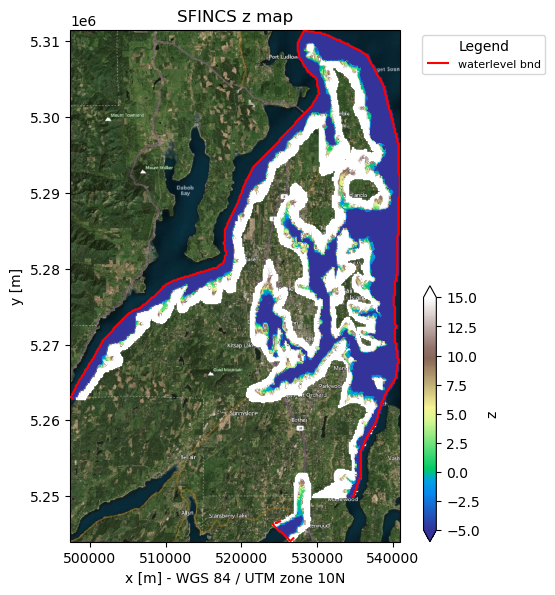

In [5]:
sf.plot_basemap(
    variable="elevation", plot_region=False, plot_geoms = False, 
    plot_bounds=True, bmap="sat", vmin=-5, vmax=15,
)

(<Figure size 600x664.916 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS manning map'}, xlabel='x [m] - WGS 84 / UTM zone 10N', ylabel='y [m]'>)

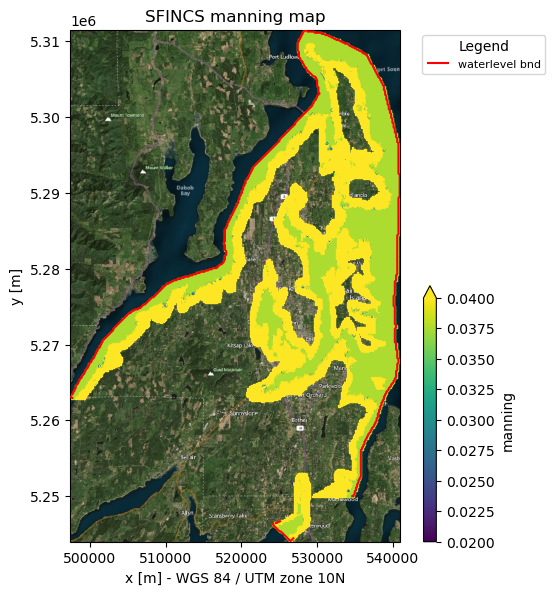

In [6]:
sf.plot_basemap(
    variable="manning", plot_region=False, plot_geoms = False, 
    plot_bounds=True, bmap="sat", vmin=0.02, vmax=0.04,
)

In [7]:
import xugrid as xu

x_qtr = xu.load_dataset(parent_dir + 'sfincs.nc')
x_qtr.z.ugrid.to_netcdf(parent_dir + 'qtr_z.nc')
x_qtr.mask.astype(float).ugrid.to_netcdf(parent_dir + 'qtr_mask.nc')

## Prepare Bulk Inputs

### Imports, file names, and shared input files

In [8]:
import xarray as xr
import numpy as np
import os
import utm

parent_dir = '/home/cassandra/Kitsap/2026-05-17/'
template_file = parent_dir + 'sfincs_template.inp'

# Load discharge and water level data set
# I reformatted the wflow output, selecting only the discharge points I wanted
# I also remapped some of the input points from approx to exact thalwegs
discharge  = xr.open_dataset(parent_dir + 'sfincs_input_discharge_remap.nc')
da_loc_array = np.column_stack([discharge.x.values, discharge.y.values])

# DFM output needs a little reformatting for my use...
waterlevel = xr.open_dataset('/media/cassandra/Expansion/Regional_ERA5_WlWaves_Kitsap.nc')
minutes = waterlevel.time.values.astype(int)
time = np.datetime64('1940-01-01T00:00') + minutes.astype('timedelta64[m]')
lat, lon = waterlevel.lat_wl.values, waterlevel.lon_wl.values
x, y, _, __ = utm.from_latlon(lat, lon)
wl_loc_array = np.column_stack([x, y])

# Make input files associated with the water level / discharge source locations
np.savetxt(parent_dir + "sfincs.src", da_loc_array, fmt="%.3f")
np.savetxt(parent_dir + "sfincs.bnd", wl_loc_array, fmt="%.3f")

In [9]:
def make_model(t0, tf, model_dir, DTMAPOUT='2592000'):
    # Discharge Input
    sda = discharge.sel(time=slice(t0, tf))
    Q = sda.discharge.values  # shape (T, L)
    # Convert time coordinates to elapsed seconds from t0
    time_seconds = (sda.time.values - t0) / np.timedelta64(1, 's')
    # Format and save
    out = np.column_stack([time_seconds, Q])
    fmt = ["%.1f"] + ["%.3f"] * Q.shape[1]
    np.savetxt(model_dir + "sfincs.dis", out, fmt=fmt)

    # Water Level Input
    swl = waterlevel.sel(time=slice(t0, tf))
    eta = swl.tide.values  # shape (T, L)
    # Convert time coordinates to elapsed seconds from t0
    time_seconds = (swl.time.values - t0) / np.timedelta64(1, 's')
    # Format and save
    out = np.column_stack([time_seconds, eta.T])
    fmt = ["%.1f"] + ["%.3f"] * eta.shape[0]
    np.savetxt(model_dir + "sfincs.bzs", out, fmt=fmt)

    # Create sfincs.inp from template
    input_template_file = open(template_file, 'r')
    input_template = input_template_file.read()
    tstart = str(t0)[:10].replace('-', '') + ' ' + str(t0)[11:].replace(':', '')
    tstop  = str(tf)[:10].replace('-', '') + ' ' + str(tf)[11:].replace(':', '')
    input_file_content = input_template.format(TSTART=tstart, 
                                               TSTOP=tstop, 
                                               TREF=tstart,
                                               DTMAPOUT=DTMAPOUT)
    input_file = open(model_dir + 'sfincs.inp', "w")
    input_file.write(input_file_content)
    input_file.close()

In [10]:
# Buffer for spinup time. 1 week. 
buffer = np.timedelta64(7*24*60, 'm')

# For each WATER year... 
for year in np.arange(1942, 2024, 1):
    
    # Get start and stop timestamps
    # Water year for 2000 runs from 1999-10-01 through 2000-09-30 so...
    t0 = np.datetime64(str(year-1) + '-10-01T00:00') - buffer
    tf = np.datetime64(str(year)   + '-10-01T00:00')

    # Make model directory
    model_dir = parent_dir + str(year) + '/'
    if not os.path.exists(model_dir):
        os.mkdir(model_dir)

    # Make model input files
    make_model(t0, tf, model_dir)

In [ ]:
# Feb 2016 benchmark event
t0 = np.datetime64('2016-02-10T00:00')
tf = np.datetime64('2016-02-25T00:00')

model_dir = parent_dir + "benchmark" + '/'
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

make_model(t0, tf, model_dir, DTMAPOUT='1800')

## Benchmark Read / Sanity Check

In [1]:
from hydromt_sfincs import SfincsModel

parent_dir = '/home/cassandra/Kitsap/2026-05-17/'
bench_dir = parent_dir + 'benchmark/'

sf = SfincsModel(root=bench_dir, mode="r")
sf.output.read()

No region component found in components.
File /home/cassandra/Kitsap/2026-05-17/benchmark/sfincs_his.nc not found.
Replacing result: inp
Replacing result: crs
Replacing result: zb
Replacing result: msk
Replacing result: zs
Replacing result: zsmax
Replacing result: qmax
Replacing result: total_runtime
Replacing result: average_dt
Replacing result: status
File /home/cassandra/Kitsap/2026-05-17/benchmark/sfincs_his.nc not found.


In [2]:
list(sf.output.data.keys())

['inp',
 'crs',
 'zb',
 'msk',
 'zs',
 'zsmax',
 'qmax',
 'total_runtime',
 'average_dt',
 'status']

In [3]:
zsmax = sf.output.data["zsmax"].max(dim="timemax")

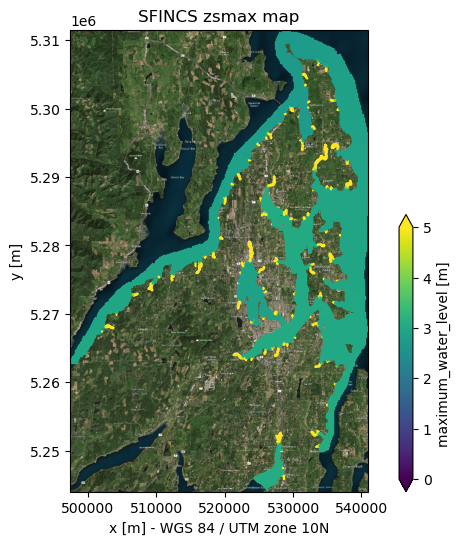

In [8]:
fig, ax = sf.plot_basemap(
    fn_out=None,
    figsize=(8, 6),
    variable=zsmax,
    plot_bounds=False,
    plot_geoms=False,
    bmap="sat",
    zoomlevel=12,
    vmin=0.0,
    vmax=5.0,
    cbar_kwargs={"shrink": 0.6, "anchor": (0, 0)},
)